# Notebook concernant l'utilisation de la librairie RSML d'openalea

Le package RSML de python permet: 

- D'importer/exporter des fichier .rsml
- D'effectuer des visualisation (plot) des architectures racinaires
- D'effectuer des mesures sur les système racinaires ainsi enregistrés

## Installation 

#### Avec ```pip3```

```python
    pip3 install git+https://github.com/openalea/RSML
```

Pour des analyse prenant en compte le temps: 
```python
    pip3 install git+https://github.com/openalea/RSML@hirros
```

!pip3 install git+https://github.com/openalea/RSML@hirros
!pip3 install matplotlib

## Utilisation

### Imports

In [1]:
import rsml # Pour importer le module rsml
from rsml import rsml2mtg # IMPORTATION : méthode qui transforme un fichier rsml en graph sur lequel on peut effectuer des analyses
from rsml import mtg2rsml # EXPORTATION : méthode qui transforme le graph en fichier rsml
from rsml import plot2d # Pour visualiser le graph en 2D ou 3D
from copy import deepcopy
from openalea.mtg import MTG
import numpy as np

PIXEL_SIZE = 26*10e-6  # Taille d'un pixel en mètre (26 micromètres ici)

#### Utilitaires (à skip)

In [2]:
# Utilitaires pour manipuler les graphs 
def extract_mtg_at_time_t(g, t):
    g_new = deepcopy(g)

    time_prop = g_new.property("time")
    time_h_prop = g_new.property("time_hours")
    diameter_prop = g_new.property("diameter")
    geometry_prop = g_new.property("geometry")
    
    if t == -1: 
        t = max(max(time_h_prop.values()))

    def _truncate_lists(prop, idx, v):
        val = prop.get(v)
        if isinstance(val, (list, tuple)) and len(val) > idx + 1:
            prop[v] = val[: idx + 1]  # garde 0…idx
        
    to_remove = []
    for v, serie in time_prop.items():
        first_t = serie[0]
        if first_t > t:
            to_remove.append(v)
        else:
            idx = max(i for i, tau in enumerate(serie) if tau <= t)

            _truncate_lists(time_prop, idx, v)
            _truncate_lists(time_h_prop, idx, v)
            _truncate_lists(diameter_prop, idx, v)
            _truncate_lists(geometry_prop, idx, v)

            # if list is empty has 1 or less elements, remove vertex
            if len(geometry_prop[v]) <= 1:
                to_remove.append(v)

    for v in to_remove:
        try:
            g_new.remove_tree(v)
        except Exception:
            g_new.remove_vertex(v, reparent_child=False)

    return g_new

def get_corresponding_time_in_hours(graph: MTG, time):
    
    metadata = graph.graph_properties().get("metadata", {})
    obs_hours_str = metadata.get("observation-hours", None)
    if obs_hours_str is None:
        raise ValueError("Le graphe ne contient pas la clé 'observation-hours' dans ses métadonnées.")
    obs_hours = np.array([float(x) for x in obs_hours_str.split(",") if x.strip() != ""])
    return obs_hours[time]

## Visualisations

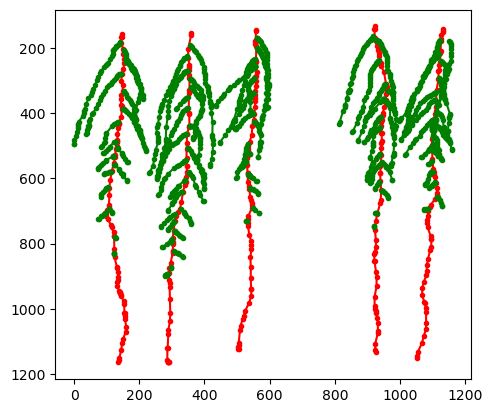

In [3]:
rsml_path = "/home/loai/Documents/code/RSMLExtraction/Results/Reconstruction_Unet_cldice_dice/Unet_cldice_dice_257/Val/230629PN031/61_prediction_before_expertized_graph.rsml" # "chemin/vers/fichier.rsml" # chemin vers le fichier rsml à étudier
graph = rsml2mtg(rsml_path) # transformation du fichier rsml en graph

plot2d(graph)  # requires matplotlib

In [4]:
import io
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, Play, jslink, HBox, VBox, Image, IntProgress, HTML

t_max = int(max(max(graph.property("time").values())))
time_label = "t"
    

t_values = list(range(0, t_max + 1)) 

fig = plt.figure()
ax = plt.gca()
plot2d(extract_mtg_at_time_t(graph, t=-1))  # -1 = dernier état (d'après ta fonction)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
plt.close(fig)

# 3) Pré-calcul des PNG en mémoire
imgs = []
progress = IntProgress(min=0, max=len(t_values), description="Pré-calcul…")
status = HTML()
display(HBox([progress, status]))

for i, t in enumerate(t_values):
    fig = plt.figure(figsize=(4, 4))
    ax = plt.gca()
    plot2d(extract_mtg_at_time_t(graph, t=t))
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal', adjustable='box')  # évite l’étirement entre frames
    ax.set_title(f"t = {t} {time_label}")

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    imgs.append(buf.getvalue())

    progress.value = i + 1
    status.value = f"{i+1}/{len(t_values)} images"

status.value = f"OK ({len(t_values)} images)"

# 4) UI: Image + Slider + Play (aucun re-plot en callback)
img_widget = Image(value=imgs[0], format='png')
slider = IntSlider(min=0, max=len(t_values)-1, step=1, value=0, description=f"t ({time_label})")
play = Play(interval=200, value=0, min=0, max=len(t_values)-1, step=1)
jslink((play, 'value'), (slider, 'value'))

def on_change(change):
    idx = change['new']
    img_widget.value = imgs[idx]

slider.observe(on_change, names='value')

VBox([HBox([play, slider]), img_widget])

In [5]:
indices_plantes = graph.vertices(scale=1)
print("Indices des plantes, de gauche à droite sur l'image :", indices_plantes) # Nombre de sommets au niveau 1

Indices des plantes, de gauche à droite sur l'image : [1, 20, 45, 63, 81]


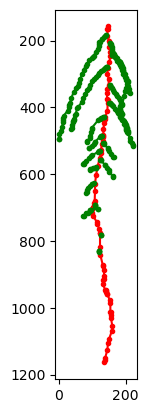

In [6]:
# Si l'on veut travailler sur une plante en particulier, on travaille sur son indice correspondant
plot2d(graph, root_id=[indices_plantes[0]])  # par exemple

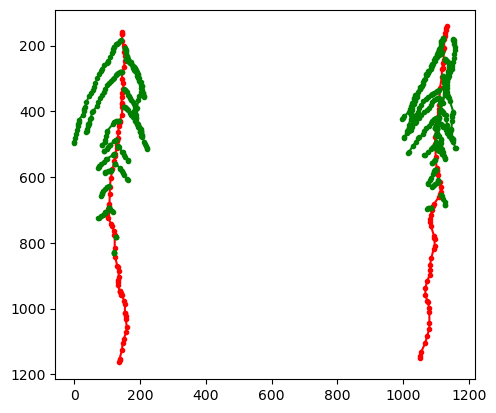

In [7]:
# ou bien
plot2d(graph, root_id=[indices_plantes[0], indices_plantes[-1]])  # par exemple

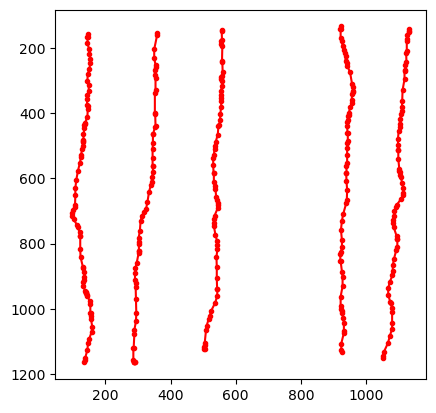

In [8]:
order = 1
plot2d(graph, order=order-1)  # Visualisation du graph d'ordre 1 (primaires)

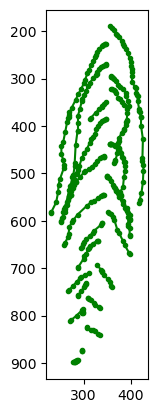

In [9]:
order = 2
plot2d(graph, root_id=[indices_plantes[1]], order=order-1)  # Visualisation du graph d'ordre 2 (latérales) pour la seconde plante (indice 20)

## Mesures

### Décompte

In [10]:
def compte_nombre_plantes(graph):
    """ 
    Compte le nombre de plantes dans le graph.
    """
    from rsml.misc import plant_vertices
    return len(plant_vertices(graph))

print("Nombre de plantes dans l'image:", compte_nombre_plantes(graph))

Nombre de plantes dans l'image: 5


In [11]:
def compte_nombres_racines(graph, plant_index = None, time = None):
    """ 
    Compte le nombre de racines dans le graph.
    Si plant_index est fourni, compte le nombre de racines pour la plante d'indice plant_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
        
    if plant_index is not None:
        from rsml.misc import root_vertices
        from openalea.mtg import MTG
        subgmtg = MTG.sub_mtg(mtg, plant_index)
        return len(root_vertices(subgmtg))
    from rsml.misc import root_vertices
    return len(root_vertices(mtg))

print("Nombre de racines dans l'image:", compte_nombres_racines(graph))
print("Nombre de racines de la plante d'indice 20:", compte_nombres_racines(graph, plant_index=indices_plantes[1]))
print("Nombre de racines de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition:", compte_nombres_racines(graph, plant_index=indices_plantes[1], time=2))

Nombre de racines dans l'image: 98
Nombre de racines de la plante d'indice 20: 24
Nombre de racines de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition: 2


In [12]:
def compte_nombres_racines_laterales(graph, plant_index = None, time = None):
    """
    Compte le nombre de racines latérales dans le graph.
    Si plant_index est fourni, compte le nombre de racines latérales pour la plante d'indice plant_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    if plant_index is not None:
        from rsml.misc import root_vertices
        from openalea.mtg import MTG
        subgraph = MTG.sub_mtg(mtg, plant_index)
        rv = root_vertices(subgraph)
        lateral_vertices = [v for v in rv if subgraph.parent(v) is not None]
        return len(lateral_vertices) if lateral_vertices else 0.0
    
    from rsml.misc import root_vertices
    rv = root_vertices(mtg)
    lateral_vertices = [v for v in rv if mtg.parent(v) is not None]
    return len(lateral_vertices) if lateral_vertices else 0.0

print("Nombre de racines latérales dans l'image:", compte_nombres_racines_laterales(graph))
print("Nombre de racines latérales de la plante d'indice 20:", compte_nombres_racines_laterales(graph, plant_index=indices_plantes[3]))

Nombre de racines latérales dans l'image: 93
Nombre de racines latérales de la plante d'indice 20: 16


### Longueur racinaires

In [13]:
def longueur_racines(graph, plant_index = None, time = None):
    """"
    Calcule la longueur totale des racines dans le graph (en mètres).
    Si plant_index est fourni, calcule la longueur totale des racines pour la plante d'indice plant_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    from rsml.misc import root_vertices
    if plant_index is not None:
        from openalea.mtg import MTG
        subgraph = MTG.sub_mtg(graph, plant_index)
        roots = root_vertices(subgraph)
        total_length = 0.0
        for root in roots:
            geometry = subgraph.property("geometry")
            polyline = geometry[root]
            for i in range(len(polyline) - 1):
                length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                          (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
                total_length += length
        return total_length * PIXEL_SIZE
    
    roots = root_vertices(mtg)
    total_length = 0.0
    for root in roots:
        geometry = graph.property("geometry")
        polyline = geometry[root]
        for i in range(len(polyline) - 1):
            length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                      (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
            total_length += length
    return total_length * PIXEL_SIZE

print("Longueur totale des racines dans l'image (en m):", longueur_racines(graph, plant_index=None))
print("Longueur totale des racines de la plante d'indice 20 (en m):", longueur_racines(graph, plant_index=indices_plantes[1]))
print("Longueur totale des racines de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition (en m):", longueur_racines(graph, plant_index=indices_plantes[0], time=0))

Longueur totale des racines dans l'image (en m): 3.968229915294066
Longueur totale des racines de la plante d'indice 20 (en m): 0.9911914791007307
Longueur totale des racines de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition (en m): 0.7201184188185361


In [14]:
def longeur_primaire(graph, plant_index, time = None):
    """"
    Calcule la longueur des racines primaires dans le graph (en mètres).
    Si plant_index est fourni, calcule la longueur totale des racines pour la plante d'indice plant_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    from rsml.misc import root_vertices
    if plant_index is not None:
        from openalea.mtg import MTG
        subgraph = MTG.sub_mtg(mtg, plant_index)
        roots = root_vertices(subgraph)
        total_length = 0.0
        for root in roots:
            if subgraph.order(root) != 0:
                continue
            geometry = subgraph.property("geometry")
            polyline = geometry[root]
            for i in range(len(polyline) - 1):
                length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                          (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
                total_length += length
        return total_length * PIXEL_SIZE
    
    roots = root_vertices(mtg)
    total_length = 0.0
    for root in roots:
        if graph.order(root) != 0:
            continue
        geometry = graph.property("geometry")
        polyline = geometry[root]
        for i in range(len(polyline) - 1):
            length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                      (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
            total_length += length
    return total_length * PIXEL_SIZE

print("Longueur totale des racines primaires dans l'image (en m):", longeur_primaire(graph, plant_index=None))
print("Longueur totale des racines primaires de la plante d'indice 20 (en m):", longeur_primaire(graph, plant_index=indices_plantes[0]))
print("Longueur totale des racines primaires de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition (en m):", longeur_primaire(graph, plant_index=indices_plantes[0], time=0))

Longueur totale des racines primaires dans l'image (en m): 1.328928505222935
Longueur totale des racines primaires de la plante d'indice 20 (en m): 0.26892492433877807
Longueur totale des racines primaires de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition (en m): 0.049477573970910065


In [15]:
def longeur_laterales(graph, plant_index, time = None):
    """"
    Calcule la longueur des racines latérales dans le graph (en mètres).
    Si plant_index est fourni, calcule la longueur totale des racines pour la plante d'indice plant_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    from rsml.misc import root_vertices
    if plant_index is not None:
        from openalea.mtg import MTG
        subgraph = MTG.sub_mtg(mtg, plant_index)
        roots = root_vertices(subgraph)
        total_length = 0.0
        for root in roots:
            if subgraph.order(root) != 1:
                continue
            geometry = subgraph.property("geometry")
            polyline = geometry[root]
            for i in range(len(polyline) - 1):
                length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                          (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
                total_length += length
        return total_length * PIXEL_SIZE
    
    roots = root_vertices(mtg)
    total_length = 0.0
    for root in roots:
        if graph.order(root) !=1:
            continue
        geometry = graph.property("geometry")
        polyline = geometry[root]
        for i in range(len(polyline) - 1):
            length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                      (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
            total_length += length
    return total_length * PIXEL_SIZE

print("Longueur totale des racines latérales dans l'image (en m):", longeur_laterales(graph, plant_index=None))
print("Longueur totale des racines latérales de la plante d'indice 20 (en m):", longeur_laterales(graph, plant_index=indices_plantes[0]))
print("Longueur totale des racines latérales de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition (en m):", longeur_laterales(graph, plant_index=indices_plantes[0], time=2))

Longueur totale des racines latérales dans l'image (en m): 2.639301410071123
Longueur totale des racines latérales de la plante d'indice 20 (en m): 0.45119349447975854
Longueur totale des racines latérales de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition (en m): 0.0007353910524340096


### Enveloppe convexe

In [16]:
def convex_hull(graph, plant_index, time = None):
    """
    Calcule l'aire du convex hull englobant toutes les racines dans le graph (en m²).
    Si plant_index est fourni, calcule l'aire du convex hull pour la plante d'indice plant_index.
    """
    import numpy as np
    from scipy.spatial import ConvexHull

    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    
    from rsml.misc import root_vertices
    from openalea.mtg import MTG
    subgraph = MTG.sub_mtg(mtg, plant_index)
    roots = root_vertices(subgraph)
    points = []
    for root in roots:
        geometry = subgraph.property("geometry")
        polyline = geometry[root]
        points.extend(polyline)
        
    if len(points) < 3:
        return 0.0  # Pas assez de points pour former un polygone

    points = np.array(points) * PIXEL_SIZE  # Convertir en mètres
    hull = ConvexHull(points)
    return hull.area

print("Aire du convex hull englobant toutes les racines de la plante d'indice 20 (en m²):", convex_hull(graph, plant_index=indices_plantes[1]))
print("Aire du convex hull englobant toutes les racines de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition (en m²):", convex_hull(graph, plant_index=indices_plantes[0], time=0))

Aire du convex hull englobant toutes les racines de la plante d'indice 20 (en m²): 0.5383644053130743
Aire du convex hull englobant toutes les racines de la plante d'indice 20 jusqu'à la 10eme capture après la première acquisition (en m²): 0.09716874093379042


### Vitesse de croissance

In [17]:
def vitesse_croissance_primaire(graph, plant_index, time1, time2):
    """
    Calcule la vitesse de croissance des racines primaires entre deux temps donnés (en m/h).
    plant_index : indice de la plante à analyser
    time1 : temps initial (en heures)
    time2 : temps final (en heures)
    """
    longueur_t1 = longeur_primaire(graph, plant_index=plant_index, time=time1)
    longueur_t2 = longeur_primaire(graph, plant_index=plant_index, time=time2)
    
    if time2 <= time1:
        raise ValueError("time2 doit être supérieur à time1")

    vitesse = (longueur_t2 - longueur_t1) / (get_corresponding_time_in_hours(graph, time2) - get_corresponding_time_in_hours(graph, time1))  # en m/h
    return vitesse

print("Vitesse de croissance des racines primaires de la plante d'indice 20 entre t=0h et t=10h (en m/h):", vitesse_croissance_primaire(graph, plant_index=indices_plantes[1], time1=0, time2=10))

Vitesse de croissance des racines primaires de la plante d'indice 20 entre t=0h et t=10h (en m/h): 0.0009393249552966326


In [18]:
def vitesse_croissance_laterales(graph, plant_index, time1, time2):
    """
    Calcule la vitesse de croissance des racines latérales entre deux temps donnés (en m/h).
    plant_index : indice de la plante à analyser
    time1 : temps initial (en heures)
    time2 : temps final (en heures)
    """
    longueur_t1 = longeur_laterales(graph, plant_index=plant_index, time=time1)
    longueur_t2 = longeur_laterales(graph, plant_index=plant_index, time=time2)
    
    if time2 <= time1:
        raise ValueError("time2 doit être supérieur à time1")
    
    vitesse = (longueur_t2 - longueur_t1) / (get_corresponding_time_in_hours(graph, time2) - get_corresponding_time_in_hours(graph, time1))  # en m/h
    return vitesse

print("Vitesse de croissance des racines latérales de la plante d'indice 20 entre t=0h et t=10h (en m/h):", vitesse_croissance_laterales(graph, plant_index=indices_plantes[1], time1=0, time2=10))

Vitesse de croissance des racines latérales de la plante d'indice 20 entre t=0h et t=10h (en m/h): 0.0004559821953576968


In [19]:
def acceleration_croissance_primaire(graph, plant_index, time1, time2, time3):
    """
    Calcule l'accélération de croissance des racines primaires entre trois temps donnés (en m/h²).
    plant_index : indice de la plante à analyser
    time1 : premier temps (en heures)
    time2 : deuxième temps (en heures)
    time3 : troisième temps (en heures)
    """
    vitesse1 = vitesse_croissance_primaire(graph, plant_index, time1, time2)
    vitesse2 = vitesse_croissance_primaire(graph, plant_index, time2, time3)
    
    if time3 <= time2 or time2 <= time1:
        raise ValueError("time3 doit être supérieur à time2 et time2 doit être supérieur à time1")
    
    acceleration = (vitesse2 - vitesse1) / (get_corresponding_time_in_hours(graph, time3) - get_corresponding_time_in_hours(graph, time1))  # en m/h²
    return acceleration

def acceleration_croissance_laterales(graph, plant_index, time1, time2, time3):
    """
    Calcule l'accélération de croissance des racines latérales entre trois temps donnés (en m/h²).
    plant_index : indice de la plante à analyser
    time1 : premier temps (en heures)
    time2 : deuxième temps (en heures)
    time3 : troisième temps (en heures)
    """
    vitesse1 = vitesse_croissance_laterales(graph, plant_index, time1, time2)
    vitesse2 = vitesse_croissance_laterales(graph, plant_index, time2, time3)
    
    if time3 <= time2 or time2 <= time1:
        raise ValueError("time3 doit être supérieur à time2 et time2 doit être supérieur à time1")
    
    acceleration = (vitesse2 - vitesse1) / (get_corresponding_time_in_hours(graph, time3) - get_corresponding_time_in_hours(graph, time1))  # en m/h²
    return acceleration

print("Accélération de croissance des racines primaires de la plante d'indice 20 entre t=0h, t=10h et t=20h (en m/h²):", acceleration_croissance_primaire(graph, plant_index=indices_plantes[1], time1=0, time2=10, time3=20))
print("Accélération de croissance des racines latérales de la plante d'indice 20 entre t=0h, t=10h et t=20h (en m/h²):", acceleration_croissance_laterales(graph, plant_index=indices_plantes[1], time1=0, time2=10, time3=20))

Accélération de croissance des racines primaires de la plante d'indice 20 entre t=0h, t=10h et t=20h (en m/h²): 4.573519595402781e-06
Accélération de croissance des racines latérales de la plante d'indice 20 entre t=0h, t=10h et t=20h (en m/h²): 1.9951197592751174e-05


## Plot évolutions

### Utilitaire

In [20]:
# %% [markdown]
# ### Utils pour séries temporelles (à exécuter une seule fois)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# axe de temps (indices entiers 0..t_max)
obs_hours_str = graph.graph_properties().get("metadata", {}).get("observation-hours", None)
T = np.array([float(x) for x in obs_hours_str.split(",") if x.strip() != ""])

# sélection d'une plante d'exemple pour les courbes "par plante"
# (modifie ici si tu veux une autre plante)
TARGET_PLANT = indices_plantes[1] if len(indices_plantes) else None

def serie_temps(func, *, plant_index=None):
    """
    Retourne une série temporelle en évaluant `func(graph, plant_index=?, time=t)` pour t dans T.
    `func` doit accepter (graph, plant_index=?, time=?).
    """
    vals = []
    for t in T:
        try:
            vals.append(func(graph, plant_index=plant_index, time=T.tolist().index(t)))
        except TypeError:
            # certaines fonctions n'acceptent pas plant_index=None ; on appelle sans l'arg si besoin
            vals.append(func(graph, time=T.tolist().index(t)))
    return np.array(vals, dtype=float)

def diff_centrale(y, dt=1.0):
    """Vitesse par différences finies centrées (mieux pour le lissage)."""
    y = np.asarray(y, dtype=float)
    v = np.empty_like(y)
    v[0] = (y[1] - y[0]) / dt
    v[-1] = (y[-1] - y[-2]) / dt
    v[1:-1] = (y[2:] - y[:-2]) / (2*dt)
    return v

def accel(y, dt=1.0):
    """Accélération = dérivée de la vitesse (toujours différences finies)."""
    return diff_centrale(diff_centrale(y, dt=dt), dt=dt)

def plot_series(ts_dict, title, ylabel, xlabel="Temps (t)", legend_loc="best"):
    plt.figure(figsize=(6,4))
    for label, y in ts_dict.items():
        plt.plot(T, y, label=label)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=.3)
    if len(ts_dict) > 1:
        plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.show()


### Décompte

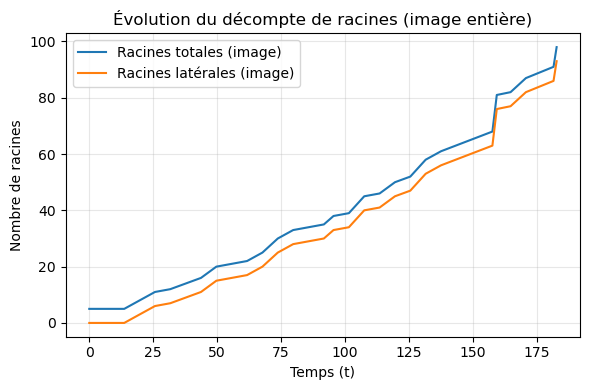

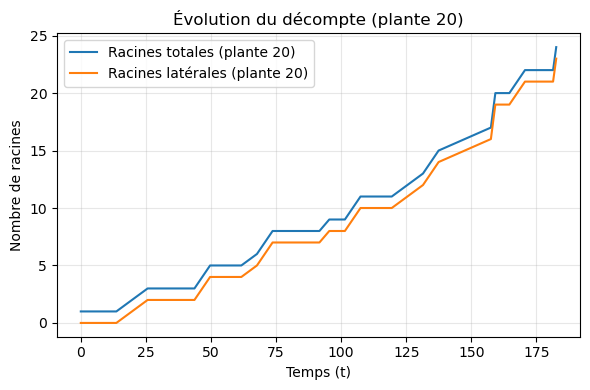

In [21]:
# %% [markdown]
# ### Décompte : nb de racines (total et latérales)

# %%
# 1) Image entière
roots_total_all = serie_temps(compte_nombres_racines, plant_index=None)
roots_lat_all   = serie_temps(compte_nombres_racines_laterales, plant_index=None)

plot_series(
    {
        "Racines totales (image)": roots_total_all,
        "Racines latérales (image)": roots_lat_all,
    },
    title="Évolution du décompte de racines (image entière)",
    ylabel="Nombre de racines"
)

# 2) Pour une plante
if TARGET_PLANT is not None:
    roots_total_plant = serie_temps(compte_nombres_racines, plant_index=TARGET_PLANT)
    roots_lat_plant   = serie_temps(compte_nombres_racines_laterales, plant_index=TARGET_PLANT)

    plot_series(
        {
            f"Racines totales (plante {TARGET_PLANT})": roots_total_plant,
            f"Racines latérales (plante {TARGET_PLANT})": roots_lat_plant,
        },
        title=f"Évolution du décompte (plante {TARGET_PLANT})",
        ylabel="Nombre de racines"
    )


### Longeurs

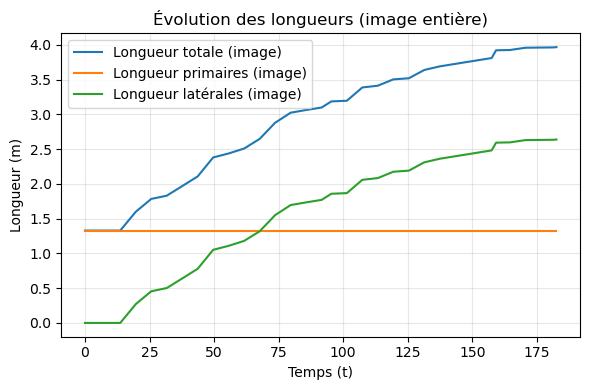

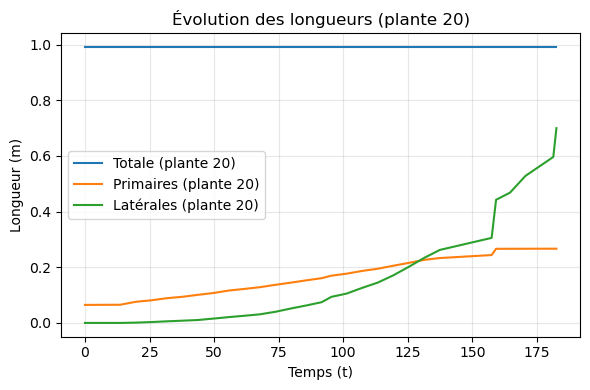

In [22]:
# %% [markdown]
# ### Longueurs : total, primaires, latérales

# %%
# 1) Image entière
len_all_total = serie_temps(longueur_racines, plant_index=None)
len_all_prim  = serie_temps(longeur_primaire, plant_index=None)
len_all_lat   = serie_temps(longeur_laterales, plant_index=None)

plot_series(
    {
        "Longueur totale (image)": len_all_total,
        "Longueur primaires (image)": len_all_prim,
        "Longueur latérales (image)": len_all_lat,
    },
    title="Évolution des longueurs (image entière)",
    ylabel="Longueur (m)"
)

# 2) Pour une plante
if TARGET_PLANT is not None:
    len_p_total = serie_temps(longueur_racines, plant_index=TARGET_PLANT)
    len_p_prim  = serie_temps(longeur_primaire, plant_index=TARGET_PLANT)
    len_p_lat   = serie_temps(longeur_laterales, plant_index=TARGET_PLANT)

    plot_series(
        {
            f"Totale (plante {TARGET_PLANT})": len_p_total,
            f"Primaires (plante {TARGET_PLANT})": len_p_prim,
            f"Latérales (plante {TARGET_PLANT})": len_p_lat,
        },
        title=f"Évolution des longueurs (plante {TARGET_PLANT})",
        ylabel="Longueur (m)"
    )


### Enveloppe convexe

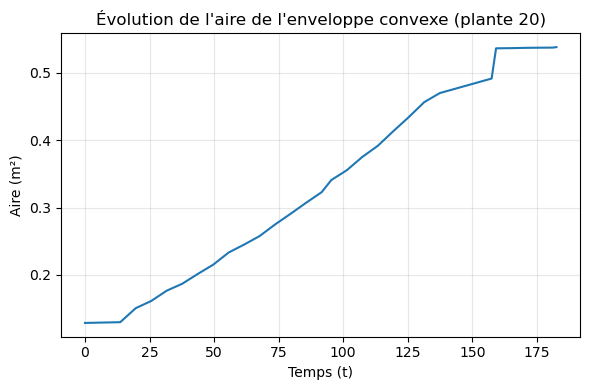

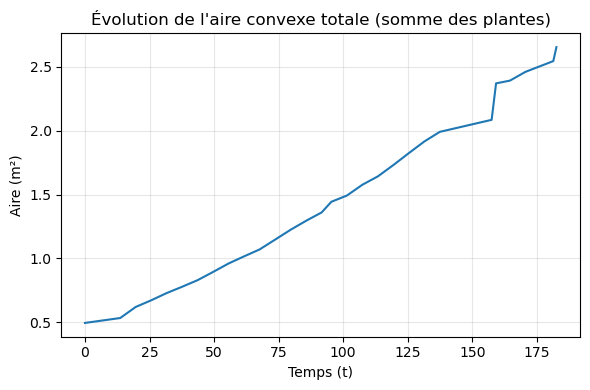

In [23]:
# %% [markdown]
# ### Enveloppe convexe (par plante)

# %%
if TARGET_PLANT is not None:
    hull_area = np.array([convex_hull(graph, plant_index=TARGET_PLANT, time=T.tolist().index(t)) for t in T], dtype=float)
    plot_series(
        {f"Aire enveloppe convexe (plante {TARGET_PLANT})": hull_area},
        title=f"Évolution de l'aire de l'enveloppe convexe (plante {TARGET_PLANT})",
        ylabel="Aire (m²)"
    )

# (optionnel) aire totale = somme des plantes présentes à chaque t
def hull_total_all_plants(graph):
    areas = []
    for t in T:
        a = 0.0
        for pid in indices_plantes:
            try:
                a += float(convex_hull(graph, plant_index=pid, time=T.tolist().index(t)))
            except Exception:
                pass
        areas.append(a)
    return np.array(areas, dtype=float)

hull_all = hull_total_all_plants(graph)
plot_series(
    {"Somme des aires (toutes plantes)": hull_all},
    title="Évolution de l'aire convexe totale (somme des plantes)",
    ylabel="Aire (m²)"
)


### Vitesses et accélérations

Pas de temps moyen : 6.52 h


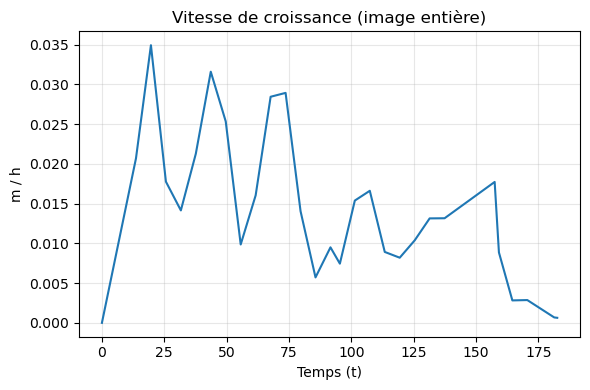

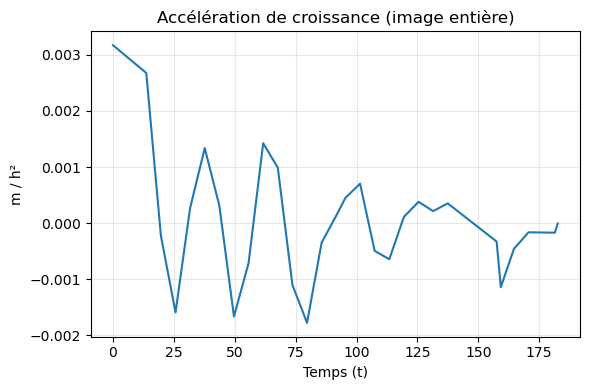

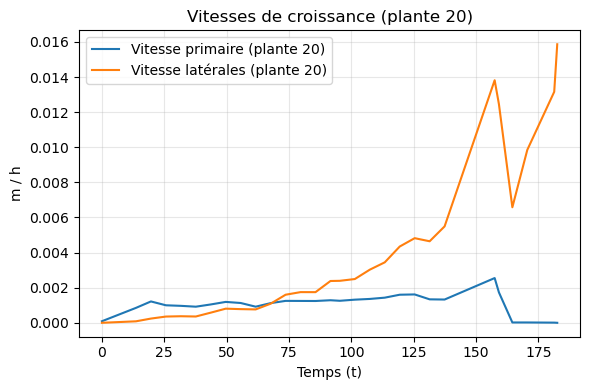

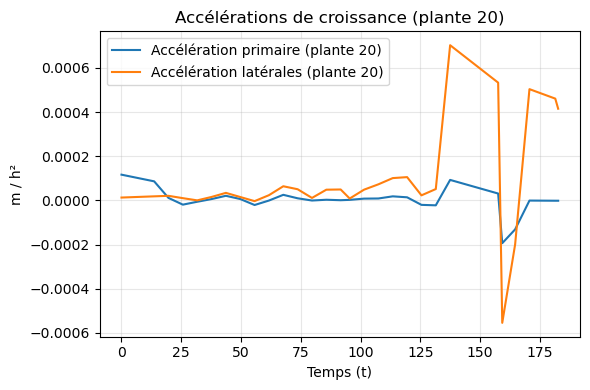

In [24]:
# %% [markdown]
# ### Vitesses et accélérations (à partir des longueurs)

# %%
dt = np.mean(np.diff(T))  # pas de temps moyen (en heures)
print(f"Pas de temps moyen : {dt:.2f} h")

# Image entière : vitesse/accélération de la longueur totale
v_all = diff_centrale(len_all_total, dt=dt)         # m / h
a_all = accel(len_all_total, dt=dt)                 # m / h²

plot_series({"Vitesse (image)": v_all}, title="Vitesse de croissance (image entière)", ylabel="m / h")
plot_series({"Accélération (image)": a_all}, title="Accélération de croissance (image entière)", ylabel="m / h²")

# Plante : vitesses/accélérations primaires vs latérales
if TARGET_PLANT is not None:
    v_p_prim = diff_centrale(len_p_prim, dt=dt)
    v_p_lat  = diff_centrale(len_p_lat,  dt=dt)
    a_p_prim = accel(len_p_prim, dt=dt)
    a_p_lat  = accel(len_p_lat,  dt=dt)

    plot_series(
        {
            f"Vitesse primaire (plante {TARGET_PLANT})": v_p_prim,
            f"Vitesse latérales (plante {TARGET_PLANT})": v_p_lat,
        },
        title=f"Vitesses de croissance (plante {TARGET_PLANT})",
        ylabel="m / h"
    )

    plot_series(
        {
            f"Accélération primaire (plante {TARGET_PLANT})": a_p_prim,
            f"Accélération latérales (plante {TARGET_PLANT})": a_p_lat,
        },
        title=f"Accélérations de croissance (plante {TARGET_PLANT})",
        ylabel="m / h²"
    )


## Exportation

In [25]:
# %% [markdown]
# ### Export : mesures pour toutes les plantes et tous les temps

# %%
import numpy as np
import pandas as pd
from collections import defaultdict

# --- Liste des plantes (niveau 1) ---
plant_ids = list(indices_plantes)  # déjà calculé plus haut

# --- Collecte des mesures ---
rows = []

for pid in plant_ids:
    for t in T:
        try:
            row = {
                "plant_id": int(pid),
                "t_index": int(T.tolist().index(t)),
                "time_hours": (float(t) if (T is not None and not np.isnan(t)) else np.nan),

                # Décompte
                "roots_total": float(compte_nombres_racines(graph, plant_index=pid, time=t)),
                "roots_lateral": float(compte_nombres_racines_laterales(graph, plant_index=pid, time=t)),

                # Longueurs (m)
                "length_total_m": float(longueur_racines(graph, plant_index=pid, time=t)),
                "length_primary_m": float(longeur_primaire(graph, plant_index=pid, time=t)),
                "length_lateral_m": float(longeur_laterales(graph, plant_index=pid, time=t)),

                # Enveloppe convexe (m²)
                "convex_hull_area_m2": float(convex_hull(graph, plant_index=pid, time=t)),
            }
        except Exception as e:
            # En cas de souci ponctuel, on remplit avec NaN pour ne pas casser tout l'export
            row = {
                "plant_id": int(pid),
                "t_index": int(T.tolist().index(t)),
                "time_hours": (float(t) if (T is not None and not np.isnan(t)) else np.nan),
                "roots_total": np.nan,
                "roots_lateral": np.nan,
                "length_total_m": np.nan,
                "length_primary_m": np.nan,
                "length_lateral_m": np.nan,
                "convex_hull_area_m2": np.nan,
                "_error": str(e),
            }
        rows.append(row)

df_measures = pd.DataFrame(rows).sort_values(["plant_id", "t_index"]).reset_index(drop=True)

# --- (Optionnel) Ajout d'une ligne d'agrégat "ALL" par temps (somme des plantes) ---
agg = (
    df_measures
    .groupby("t_index", as_index=False)[["roots_total","roots_lateral","length_total_m","length_primary_m","length_lateral_m","convex_hull_area_m2"]]
    .sum(min_count=1)
)
if T is not None:
    T_hours = [float(t) if not np.isnan(t) else np.nan for t in T]
else:
    T_hours = None
agg["plant_id"] = "ALL"
df_all = agg[["plant_id", "t_index"]].copy()
df_all["time_hours"] = [T_hours[i] for i in agg["t_index"]]
df_all["roots_total"] = agg["roots_total"]
df_all["roots_lateral"] = agg["roots_lateral"]
df_all["length_total_m"] = agg["length_total_m"]
df_all["length_primary_m"] = agg["length_primary_m"]
df_all["length_lateral_m"] = agg["length_lateral_m"]
df_all["convex_hull_area_m2"] = agg["convex_hull_area_m2"]

df_export = pd.concat([df_measures, df_all], ignore_index=True)

# --- Sauvegardes ---
csv_path = "rsml_measures_all_plants_all_times.csv"
parquet_path = "rsml_measures_all_plants_all_times.parquet"

df_export.to_csv(csv_path, index=False)
try:
    df_export.to_parquet(parquet_path, index=False)  # rapide/compact si pyarrow est dispo
except Exception:
    parquet_path = None

print(f"Export CSV -> {csv_path}")
if parquet_path:
    print(f"Export Parquet -> {parquet_path}")

df_export.head()


Export CSV -> rsml_measures_all_plants_all_times.csv


,plant_id,t_index,time_hours,roots_total,roots_lateral,length_total_m,length_primary_m,length_lateral_m,convex_hull_area_m2
0,1,0,0.0000,1.0,0.0,0.720118,0.049478,0.000000,0.097169
1,1,1,13.6601,6.0,5.0,0.720118,0.125222,0.051543,0.251913
2,1,2,19.6570,8.0,7.0,0.720118,0.165414,0.116765,0.333091
3,1,3,25.6639,16.0,15.0,0.720118,0.233690,0.306310,0.470250
4,1,4,31.6593,18.0,17.0,0.720118,0.268925,0.451193,0.539776


In [26]:

import numpy as np
import pandas as pd

def derivs_from_series(y, x):
    """
    Renvoie (v, a) = (dy/dx, d²y/dx²) via numpy.gradient,
    gérant proprement les NaN (interpolation locale).
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    # masque NaN
    m = ~np.isnan(y) & ~np.isnan(x)
    v = np.full_like(y, np.nan)
    a = np.full_like(y, np.nan)

    if m.sum() >= 3:
        xm = x[m]
        ym = y[m]
        vm = np.gradient(ym, xm)
        am = np.gradient(vm, xm)
        v[m] = vm
        a[m] = am
    return v, a

deriv_rows = []

time_col = "time_hours" if df_export["time_hours"].notna().any() else "t_index"

for pid, g in df_export[df_export["plant_id"]!="ALL"].groupby("plant_id"):
    g = g.sort_values("t_index")
    x = g[time_col].values.astype(float)
    if time_col == "t_index":
        # Pas constant = 1
        x = np.arange(len(g), dtype=float)

    for name in ["length_total_m", "length_primary_m", "length_lateral_m"]:
        v, a = derivs_from_series(g[name].values, x)
        deriv_rows.append(pd.DataFrame({
            "plant_id": pid,
            "t_index": g["t_index"].values,
            "time_hours": g["time_hours"].values,
            "measure": name,
            "value": g[name].values,
            "velocity_" + name: v,        # m / h si time_hours ; sinon "par pas"
            "acceleration_" + name: a,    # m / h² si time_hours ; sinon "par pas²"
        }))

df_derivs = pd.concat(deriv_rows, ignore_index=True)

csv_deriv_path = "rsml_derivatives_all_plants_all_times.csv"
df_derivs.to_csv(csv_deriv_path, index=False)
print(f"Export CSV (vitesses/accélérations) -> {csv_deriv_path}")
df_derivs.head()


Export CSV (vitesses/accélérations) -> rsml_derivatives_all_plants_all_times.csv


,plant_id,t_index,time_hours,measure,value,velocity_length_total_m,acceleration_length_total_m,velocity_length_primary_m,acceleration_length_primary_m,velocity_length_lateral_m,acceleration_length_lateral_m
0,1,0,0.0000,length_total_m,0.720118,0.000000e+00,-1.015936e-18,NaN,NaN,NaN,NaN
1,1,1,13.6601,length_total_m,0.720118,-1.387779e-17,4.941427e-19,NaN,NaN,NaN,NaN
2,1,2,19.6570,length_total_m,0.720118,-6.938894e-18,1.733214e-18,NaN,NaN,NaN,NaN
3,1,3,25.6639,length_total_m,0.720118,6.938894e-18,-5.836708e-19,NaN,NaN,NaN,NaN
4,1,4,31.6593,length_total_m,0.720118,-1.387779e-17,-2.835414e-21,NaN,NaN,NaN,NaN


## Définitions

Un $MTG$ c'est un graph sur lequel on peut itérer pour effectuer des mesures. Il est composé de plusieurs niveaux: 
- Niveau 0: contient l'ensemble du graph et de ses ramifications (i.e. 5 plantes et leurs ramifications)
- Niveau 1: contient le sous-graph correspondant à une unique plante 
- Niveau 2: contient le (sous-)sous-graph correspondant à une racine

-> Si on veut compter l'ensemble des racines de l'image, on travaille au niveau 0

-> Si on veut mesurer l'aire de l'enveloppe convexe d'une plante, on travaille au niveau 1

-> Si on veut mesurer la longeur d'une racine en particulier, on travaille au niveau 2